# Simulation-based inference with the Python package `sbijax`

In [41]:
import arviz as az
import jax
import numpy as np
import optax
import seaborn as sns


import fybdthemes
import matplotlib.pyplot as plt
import tueplots.bundles
import tueplots.axes

from jax import numpy as jnp, random as jr
from jax._src.flatten_util import ravel_pytree
from matplotlib.ticker import AutoLocator

from sbijax import SNL
from sbijax.nn import make_affine_maf
from tensorflow_probability.substrates.jax import distributions as tfd

In [42]:
custom_params = {
    'font.family':'serif', 
    'font.weight':'ultralight', 
    'font.serif':'Computer Modern',
    "axes.labelweight": "light",
    "mathtext.fontset": "stix",
    'text.usetex': True,
}
sns.set_theme(style="ticks", context='paper', rc=custom_params)
plt.rcParams.update(tueplots.bundles.icml2022())
plt.rcParams.update(tueplots.axes.lines(base_width=0.5))

## Example section 3

### Model definition

In [2]:
def prior_fn():
    prior = tfd.JointDistributionNamed(dict(
        mean=tfd.Normal(jnp.zeros(2), 1.0),
        scale=tfd.HalfNormal(jnp.ones(1)),
    ))
    return prior


def simulator_fn(seed: jr.PRNGKey, theta: dict[str, jax.Array]):
    p = tfd.Normal(jnp.zeros_like(theta["mean"]), 1.0)
    y = theta["mean"] + theta["scale"] * p.sample(seed=seed)
    return y

### Algorithm definition

In [3]:
n_dim_data = 2
n_layers, hidden_sizes = 5, (64, 64)
neural_network = make_affine_maf(n_dim_data, n_layers, hidden_sizes)
fns = prior_fn, simulator_fn
model = SNL(fns, neural_network)

### Training and inference

In [4]:
obs = jnp.array([-1.0, 1.0])
data, _ = model.simulate_data(jr.PRNGKey(0), n_simulations=10_000)
params, losses = model.fit(
    jr.PRNGKey(1), data=data
)
inference_results, diagnostics = model.sample_posterior(
    jr.PRNGKey(2), params, obs
)

 13%|█████████████████████████                                                                                                                                                                   | 133/1000 [00:37<04:04,  3.55it/s]


In [5]:
print(inference_results)

Inference data with groups:
	> posterior
	> observed_data


In [6]:
print(inference_results.posterior)

<xarray.Dataset> Size: 56kB
Dimensions:    (chain: 4, draw: 1000, mean_dim: 2, scale_dim: 1)
Coordinates:
  * chain      (chain) int64 32B 0 1 2 3
  * draw       (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * mean_dim   (mean_dim) int64 16B 0 1
  * scale_dim  (scale_dim) int64 8B 0
Data variables:
    mean       (chain, draw, mean_dim) float32 32kB -1.058 0.9226 ... 0.8237
    scale      (chain, draw, scale_dim) float32 16kB 0.1377 1.043 ... 0.2873
Attributes:
    created_at:     2024-06-04T07:30:29.581578
    arviz_version:  0.17.1


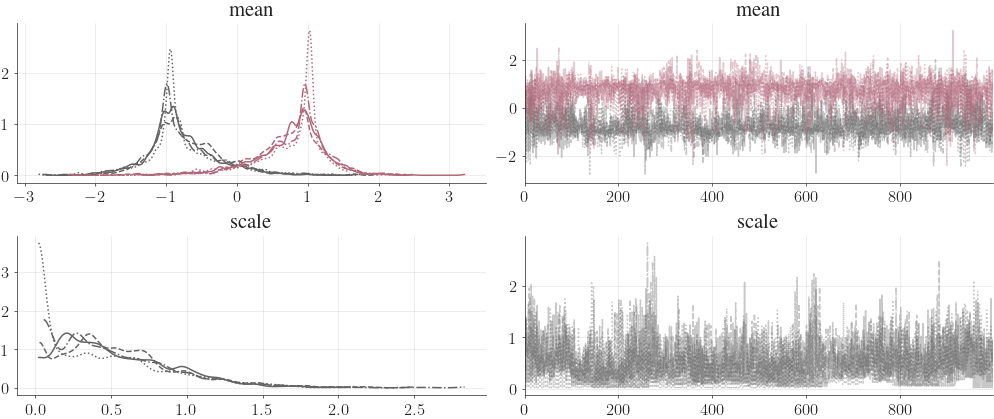

In [14]:
def plot(inference_results):
    var_sizes = inference_results.posterior.sizes
    max_dim = np.max([v for k, v in dict(var_sizes).items() if k not in ["chain", "draw"]])
    colors = sns.blend_palette([ "#636363", "#b26679"], n_colors=max_dim)    
    _, axes = plt.subplots(figsize=(10, 4.25), nrows=2, ncols=2, sharey=False, sharex=False)

    with az.style.context(["arviz-white"], after_reset=True):
        plt.rcParams["font.family"] = "Times New Roman"
        axes = az.plot_trace(
            inference_results, 
            compact_prop={"color": colors},
            axes=axes
        )
        for ax in axes.flatten():
            ax.spines[['right', 'top']].set_visible(False)
            ax.spines.left.set_linewidth(.5)
            ax.spines.bottom.set_linewidth(.5)
            ax.yaxis.set_major_locator(AutoLocator())
            ax.title.set_fontsize(15)
            ax.yaxis.set_tick_params(labelsize='large')
            ax.xaxis.set_tick_params(labelsize='large')
            ax.xaxis.set_tick_params(width=0.5, length=2)
            ax.yaxis.set_tick_params(width=0.5, length=2)
            ax.grid(which='major', axis='both', alpha=0.5)
    plt.tight_layout()
    #plt.savefig("/Users/simon/PROJECTS/2022-bistom/docs/manuscript/sbijax/figures/trace-plot.pdf")
    plt.show()
    
plot(inference_results)

### Model diagnostics

In [18]:
print(diagnostics.rhat)

<xarray.Dataset> Size: 48B
Dimensions:    (mean_dim: 2, scale_dim: 1)
Coordinates:
  * mean_dim   (mean_dim) int64 16B 0 1
  * scale_dim  (scale_dim) int64 8B 0
Data variables:
    mean       (mean_dim) float64 16B 1.004 1.002
    scale      (scale_dim) float64 8B 1.017


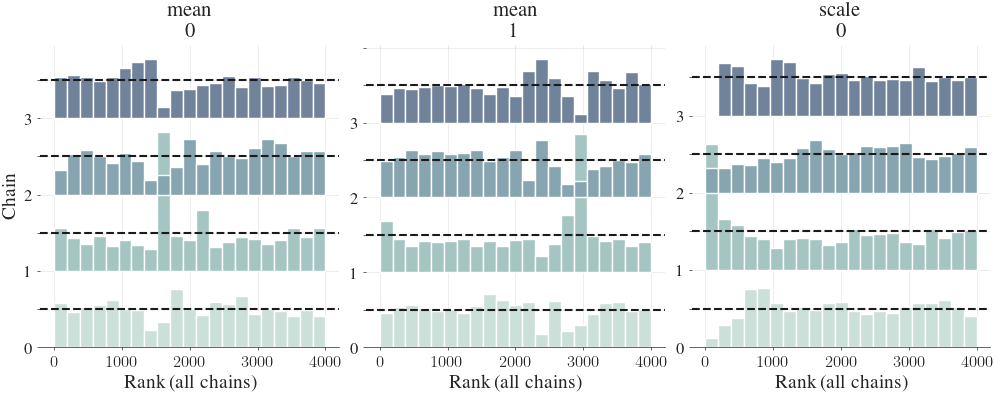

In [15]:
def plot_ranks(inference_results):
    colors = sns.cubehelix_palette(start=.5, rot=-.5,n_colors=4, hue=0.5, dark=0.5, as_cmap=False)
    _, axes = plt.subplots(figsize=(10, 4), nrows=1, ncols=3)

    with az.style.context(["arviz-doc", "arviz-viridish"], after_reset=True):
        plt.rcParams["font.family"] = "Times New Roman"
        ax = az.plot_rank(
            inference_results,
            ax=axes, 
            colors=colors, 
        )
        for i, ax in enumerate(axes):
            ax.spines[['right', 'top', 'left']].set_visible(False)
            ax.spines.left.set_linewidth(.5)
            ax.spines.bottom.set_linewidth(.5)
            ax.yaxis.set_major_locator(AutoLocator())
            ax.title.set_fontsize(15)
            if i > 0:
                ax.set_ylabel(None)
            ax.yaxis.set_tick_params(labelsize='large')
            ax.xaxis.set_tick_params(labelsize='large')
            ax.xaxis.set_tick_params(width=0.5, length=2)
            ax.yaxis.set_tick_params(width=0.5, length=2)
            ax.grid(which='major', axis='both', alpha=0.5)
    plt.tight_layout()
    #plt.savefig("/Users/simon/PROJECTS/2022-bistom/docs/manuscript/sbijax/figures/rank-plot.pdf")
    plt.show()

plot_ranks(inference_results)

In [31]:
inference_results.posterior

<xarray.Dataset> Size: 56kB
Dimensions:    (chain: 4, draw: 1000, mean_dim: 2, scale_dim: 1)
Coordinates:
  * chain      (chain) int64 32B 0 1 2 3
  * draw       (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
  * mean_dim   (mean_dim) int64 16B 0 1
  * scale_dim  (scale_dim) int64 8B 0
Data variables:
    mean       (chain, draw, mean_dim) float32 32kB -1.058 0.9226 ... 0.8237
    scale      (chain, draw, scale_dim) float32 16kB 0.1377 1.043 ... 0.2873
Attributes:
    created_at:     2024-06-04T07:30:29.581578
    arviz_version:  0.17.1

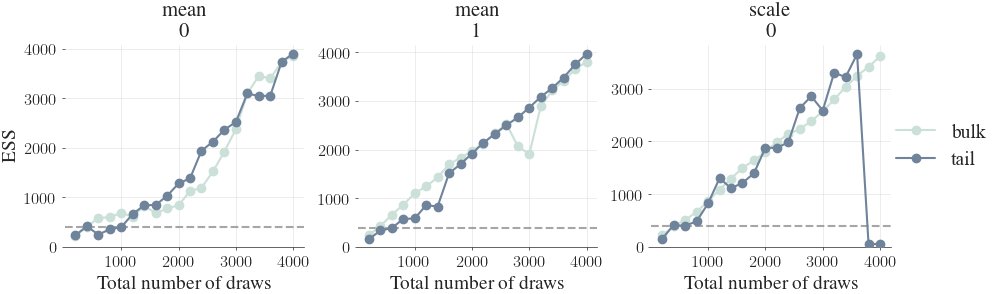

In [574]:
def plot_ess(inference_results):
    _, axes = plt.subplots(figsize=(10, 3), nrows=1, ncols=3)

    colors = sns.cubehelix_palette(start=.5, rot=-.5, n_colors=2, hue=0.5, dark=0.5, as_cmap=False)

    with az.style.context(["arviz-doc", "arviz-viridish"], after_reset=True):
        plt.rcParams["font.family"] = "Times New Roman"
        ax = az.plot_ess(
            inference_results,
            ax=axes, 
            color="#CAE0D8",
            extra_kwargs={"color": "#6F839B"},
            kind="evolution"
        )
        for i, ax in enumerate(axes):
            ax.spines[['right', 'top', 'left']].set_visible(False)
            ax.spines.left.set_linewidth(.5)
            ax.spines.bottom.set_linewidth(.5)
            ax.yaxis.set_major_locator(AutoLocator())
            ax.title.set_fontsize(15)
            if i > 0:
                ax.set_ylabel(None)
            if i < 2:
                ax.get_legend().remove()
            else:
                legend = ax.get_legend()
                ax.legend(bbox_to_anchor=(0.95, .7), frameon=False)
            ax.yaxis.set_tick_params(labelsize='large')
            ax.xaxis.set_tick_params(labelsize='large')
            ax.xaxis.set_tick_params(width=0.5, length=2)
            ax.yaxis.set_tick_params(width=0.5, length=2)
            ax.grid(which='major', axis='both', alpha=0.5)
    plt.tight_layout()
    #plt.savefig("/Users/simon/PROJECTS/2022-bistom/docs/manuscript/sbijax/figures/ess-plot.pdf")
    plt.show()

plot_ess(inference_results)

### Sequential inference

In [56]:
n_rounds = 5
data, params = None, {}
for i in range(n_rounds):        
    data, _ = model.simulate_data_and_possibly_append(
        jr.fold_in(jr.PRNGKey(0), i),
        params=params,
        observable=obs,
        data=data,
        sampler="mala",
    )
    params, info = model.fit(jr.fold_in(jr.PRNGKey(1), i), data=data)
inference_results, diagnostics = model.sample_posterior(
    jr.PRNGKey(2), params, obs
)

 12%|██████████████████████▌                                                                                                                                                                     | 120/1000 [00:26<03:17,  4.46it/s]


ValueError: Attempt to convert a value (None) with an unsupported type (<class 'NoneType'>) to a Tensor.

## Examples

In [2]:
def prior_fn():
    prior = tfd.JointDistributionNamed(dict(
        theta=tfd.Uniform(jnp.full(5, -3.0), jnp.full(5, 3.0))
    ))
    return prior


def simulator_fn(seed, theta):
    theta = theta["theta"]
    orig_shape = theta.shape
    if theta.ndim == 2:
        theta = theta[:, None, :]
    us_key, noise_key = jr.split(seed)

    def _unpack_params(ps):
        m0 = ps[..., [0]]
        m1 = ps[..., [1]]
        s0 = ps[..., [2]] ** 2
        s1 = ps[..., [3]] ** 2
        r = jnp.tanh(ps[..., [4]])
        return m0, m1, s0, s1, r

    m0, m1, s0, s1, r = _unpack_params(theta)
    us = tfd.Normal(0.0, 1.0).sample(
        seed=us_key, sample_shape=(theta.shape[0], theta.shape[1], 4, 2)
    )
    xs = jnp.empty_like(us)
    xs = xs.at[:, :, :, 0].set(s0 * us[:, :, :, 0] + m0)
    y = xs.at[:, :, :, 1].set(
        s1 * (r * us[:, :, :, 0] + jnp.sqrt(1.0 - r**2) * us[:, :, :, 1]) + m1
    )
    if len(orig_shape) == 2:
        y = y.reshape((*theta.shape[:1], 8))
    else:
        y = y.reshape((*theta.shape[:2], 8))
    return y

In [3]:
true_theta = prior_fn().sample(seed=jr.PRNGKey(12345), sample_shape=(1,))
true_theta

{'theta': Array([[ 1.5337906 , -1.7987795 , -1.4081197 ,  0.26066422, -2.001558  ]],      dtype=float32)}

In [4]:
obs = simulator_fn(jr.PRNGKey(123456), true_theta)
obs

Array([[ 3.8545444, -1.8861465,  6.4012837, -1.9895641,  2.4646997,
        -1.8218728,  3.5753257, -1.8815556]], dtype=float32)

### MCMC

In [6]:
from functools import partial
from jax import scipy as jsp
from sbijax.mcmc import sample_with_nuts, sample_with_slice

In [7]:
def likelihood_fn(theta, y):
    mu = jnp.tile(theta[:2], 4)
    s1, s2 = theta[2] ** 2, theta[3] ** 2
    corr = s1 * s2 * jnp.tanh(theta[4])
    cov = jnp.array([[s1**2, corr], [corr, s2**2]])
    cov = jsp.linalg.block_diag(*[cov for _ in range(4)])
    p = tfd.MultivariateNormalFullCovariance(mu, cov)
    return p.log_prob(y)


def log_density_fn(theta, y):
    prior_lp = tfd.JointDistributionNamed(dict(
        theta=tfd.Uniform(jnp.full(5, -3.0), jnp.full(5, 3.0))
    )).log_prob(theta)
    likelihood_lp = likelihood_fn(theta, y)
    lp = jnp.sum(prior_lp) + jnp.sum(likelihood_lp)
    return lp

In [58]:
log_density = partial(log_density_fn, y=obs)

def lp(theta):
    return jax.vmap(log_density)(theta)

slice_samples = sample_with_slice(
    jr.PRNGKey(0),
    lp,
    prior_fn().sample,
    n_chains=10, 
    n_samples=10_000, 
    n_warmup=5_000
)

/Users/simon/miniconda3/envs/sbi-dev/lib/python3.9/site-packages/jax/_src/numpy/array_methods.py:66: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype)
/Users/simon/miniconda3/envs/sbi-dev/lib/python3.9/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:339: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return np.array(value, dtype=dtype)
/Users/simon/miniconda3/envs/sbi-dev/lib/python3.9

In [137]:
slice_samples = slice_samples.reshape(-1, 5)

In [156]:
slice_samples.shape

(50000, 5)

In [157]:
def plot_posteriors(obj, save_path=None):
    _, axes = plt.subplots(figsize=(12, 10), nrows=5, ncols=5)
    with az.style.context(["arviz-doc"], after_reset=True):
        for i in range(0, 5):        
            for j in range(0, 5):
                ax = axes[i, j]
                if i < j:
                    ax.axis('off')
                else:
                    ax.hexbin(obj[..., j], obj[..., i], gridsize=100, bins='log', cmap='viridis')            
                ax.spines.left.set_linewidth(.5)
                ax.spines.bottom.set_linewidth(.5)
                ax.spines.right.set_linewidth(.5)
                ax.spines.top.set_linewidth(.5)
                ax.set_xticklabels([])
                ax.set_yticklabels([])
                ax.xaxis.set_tick_params(width=0., length=0)
                ax.yaxis.set_tick_params(width=0., length=0)
                ax.grid(which='major', axis='both', alpha=0.5)
        for i in range(5):
            axes[i, i].hist(obj[..., i], color="black")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()

In [ ]:
plot_posteriors(
    slice_samples, 
    "/Users/simon/PROJECTS/2022-bistom/docs/manuscript/sbijax/figures/posterior_pair_plot-slice.pdf"
)

### SNL

In [146]:
n_dim_data = obs.shape[-1]
n_layers, hidden_sizes = 5, (64, 64)
neural_network = make_affine_maf(n_dim_data, n_layers, hidden_sizes)
fns = prior_fn, simulator_fn
model = SNL(fns, neural_network)

In [165]:
data, params = None, {}
for i in range(10):
    data, _ = model.simulate_data(
        jr.fold_in(jr.PRNGKey(1), i),
        params=params,
        observable=obs,                
    )
    params, info = model.fit(
        jr.fold_in(jr.PRNGKey(2), i), data=data, optimizer=optax.adam(1e-3)
    )
snl_inference_results, diagnostics = model.sample_posterior(
    jr.PRNGKey(3), params, obs, n_samples=10_000, n_warmup=5000
)

 26%|███████████████████████████████████████████████▉                                                                                                                                            | 255/1000 [01:22<04:00,  3.10it/s]


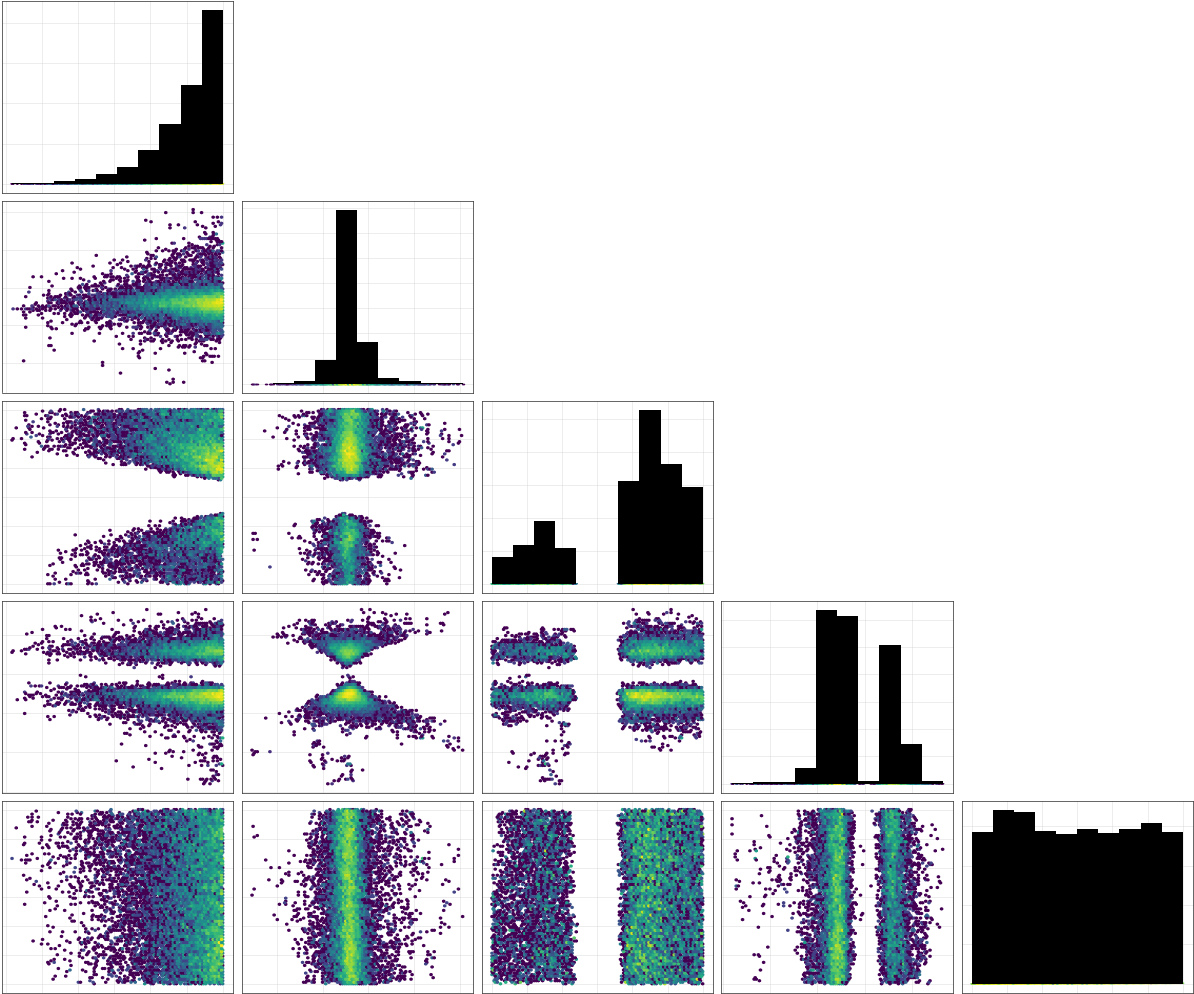

In [167]:
plot_posteriors(
    sbijax._src.mcmc.util.flatten(snl_inference_results.posterior)["theta"],
    "/Users/simon/PROJECTS/2022-bistom/docs/manuscript/sbijax/figures/posterior_pair_plot-snl.pdf"
)